## Conditional Workflow without LLM

In [14]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama


In [2]:
class SimpleState(TypedDict):
    content: str
    is_refined : bool

In [8]:
def start_node(state: SimpleState) -> SimpleState:
    return {"content": "Initial content", "is_refined": False}

def refine_node(state: SimpleState) -> SimpleState:
    return {"content": state["content"] + " (refined)", "is_refined": True}

def router_check(state: SimpleState):
    if len(state["content"]) < 30:
        return "refine"
    else:
        return "end"

In [11]:
builder = StateGraph(SimpleState)

builder.add_node("start_node", start_node)
builder.add_node("refine", refine_node)

builder.add_edge(START, "start_node")

builder.add_conditional_edges("start_node", router_check, {"refine": "refine", "end": END})

builder.add_edge("refine", END)

graph = builder.compile()



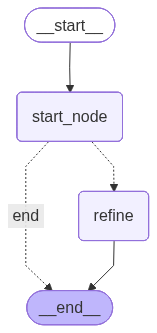

In [12]:
graph

In [13]:
print("Test : 1")
graph.invoke({
    "content": "Initial content",
    "is_refined": False
})

Test : 1


{'content': 'Initial content (refined)', 'is_refined': True}

## Conditional Workflow with LLM (The Automated Incident Responder)

In [46]:
class SentinelState(TypedDict):
    log_entry : str
    classification : str  # "bug", "threat", "normal"ArithmeticError
    action_taken: str

llm = ChatOllama(model="qwen2.5-coder:7b", temperature = 0)

In [65]:
def scanner_node(state: SentinelState) -> SentinelState:
    print("Scanning log entry...")
    return {
        "log_entry": state["log_entry"]
    }

def bug_handler(state: SentinelState) -> SentinelState:
    print("Now : DevOps finding and fixing the bug...")
    return {
        "action_taken": "logged to bug tracking system and assigned to dev team"
    }

def security_handler(state: SentinelState) -> SentinelState:
    print("Security team is analyzing the threat...")
    return {
        "action_taken": "logged to security incident response system and assigned to security team"
    }

def check_classification(state: SentinelState):
    print("LLM is analysing the severity....")
    prompt = f"""Analyze this system log: "{state['log_entry']}"
    Classify it as exactly one of these: 'bug', 'threat', or 'normal'.
    - bug: system errors, null pointers, crashes.
    - threat: unauthorized access, multiple failed logins, SQL injection.
    - normal: routine updates, user logins, heartbeat.
    response:"""

    response = llm.invoke(prompt)
    decision = response.content.lower().strip()
    if "bug" in decision:
        return "bug"
    elif "threat" in decision:
        return "threat"
    else:
        return "normal"

In [66]:
builder = StateGraph(SentinelState)

builder.add_node("scanner", scanner_node)
builder.add_node("bug_team", bug_handler)
builder.add_node("security_team", security_handler)

builder.add_edge(START, "scanner")
builder.add_conditional_edges("scanner", check_classification, {"bug": "bug_team", "threat": "security_team", "normal": END})

builder.add_edge("bug_team", END)
builder.add_edge("security_team", END)
sentinel_graph = builder.compile()

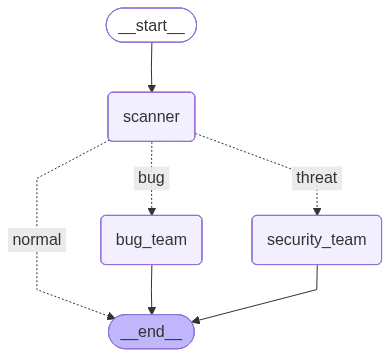

In [67]:
sentinel_graph

In [78]:
initial_log_entry = "2024-06-01 12:00:00 ERROR NullPointerException at line 42 in MyApp.java"

sentinel_graph.invoke({"log_entry": initial_log_entry})


Scanning log entry...
LLM is analysing the severity....
Now : DevOps finding and fixing the bug...


{'log_entry': '2024-06-01 12:00:00 ERROR NullPointerException at line 42 in MyApp.java',
 'action_taken': 'logged to bug tracking system and assigned to dev team'}